## Generate thesis figures - RQ2


Generates
- ΔF1 vs homogeneity threshold, one line per radius
- ΔF1 vs radius at best homogeneity threshold
- Baseline vs best clustering F1 bar chart
- Mean neighbourhood size vs radius
- Full results table

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

%matplotlib inline

***0. Paths & configuration***

In [2]:
BASE         = Path(r"C:\Users\zanca\OneDrive\Desktop\Vrij Unversiteit\extra_year\Thesis\Rapid Assessment of Earthquake Building Damage")
RESULTS_FILE = BASE / "4_spatial_context" / "plot_clustering_results" / "clustering_results.json"
FIGURES_DIR  = BASE / "4_spatial_context" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"A": "#534AB7", "B": "#0F6E56", "C": "#993C1D"}
LABELS = {
    "A": "Model A \u2014 End-to-end",
    "B": "Model B \u2014 Human-guided",
    "C": "Model C \u2014 Physics-guided",
}

plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

print(f"Results file: {RESULTS_FILE}")
print(f"Figures dir:  {FIGURES_DIR}")

Results file: C:\Users\zanca\OneDrive\Desktop\Vrij Unversiteit\extra_year\Thesis\Rapid Assessment of Earthquake Building Damage\4_spatial_context\plot_clustering_results\clustering_results.json
Figures dir:  C:\Users\zanca\OneDrive\Desktop\Vrij Unversiteit\extra_year\Thesis\Rapid Assessment of Earthquake Building Damage\4_spatial_context\figures


***1. Load clustering results***

In [3]:
if not RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Results file not found: {RESULTS_FILE}\nRun evaluate_clustering.py first."
    )

with open(RESULTS_FILE) as f:
    results = json.load(f)

print(f"Loaded results for models: {list(results.keys())}")

Loaded results for models: ['A', 'B', 'C']


***2. Figure 1 — ΔF1 vs homogeneity threshold, one panel per model***

C:\Users\zanca\AppData\Local\Temp\ipykernel_5524\1954195110.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette        = cm.get_cmap("YlOrRd", n_radii + 2)


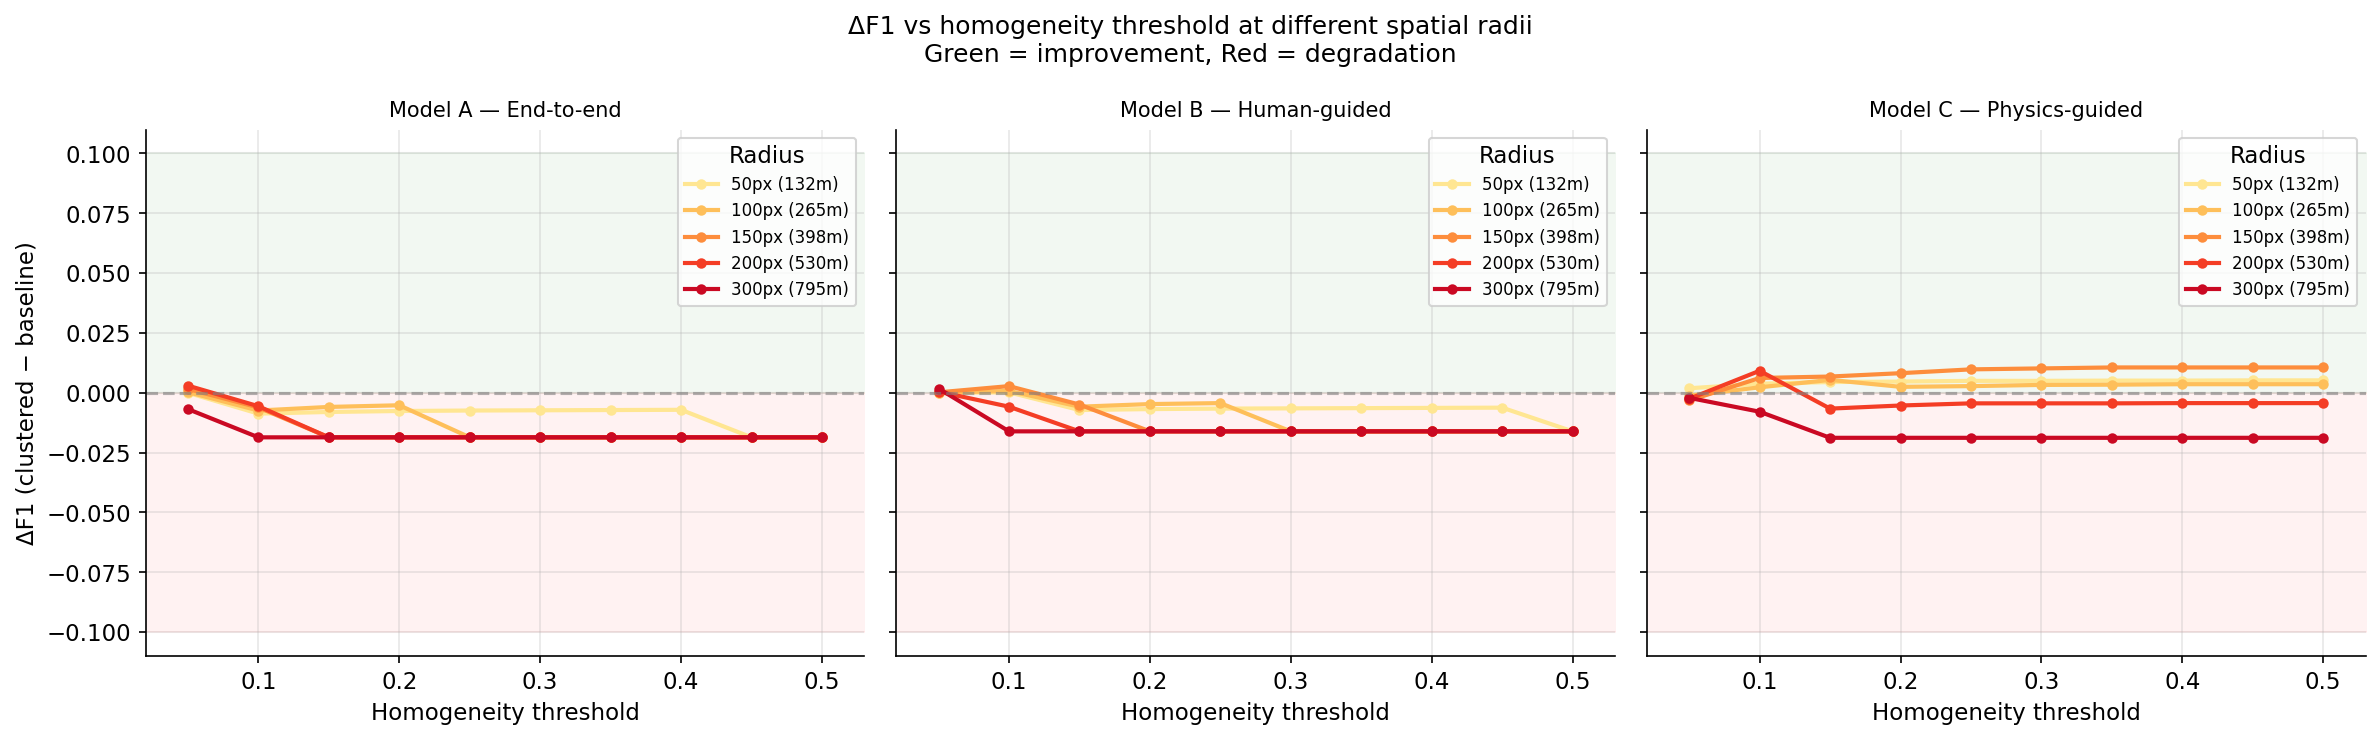

Saved: fig1_delta_f1_by_radius.png


In [4]:
def plot_delta_f1_by_radius(results):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for ax, (model_id, res) in zip(axes, results.items()):
        radius_results = res["radius_results"]
        n_radii        = len(radius_results)
        palette        = cm.get_cmap("YlOrRd", n_radii + 2)

        for i, rr in enumerate(radius_results):
            thresholds = [t["homogeneity_threshold"] for t in rr["threshold_results"]]
            deltas     = [t["delta_f1"]              for t in rr["threshold_results"]]
            ax.plot(thresholds, deltas,
                    label=f"{rr['radius_px']}px ({rr['radius_m']:.0f}m)",
                    color=palette(i + 1), linewidth=2,
                    marker="o", markersize=4)

        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.6)
        ax.fill_between([0, 0.55],  0,  0.1, alpha=0.05, color="green")
        ax.fill_between([0, 0.55], -0.1, 0,  alpha=0.05, color="red")
        ax.set_title(LABELS[model_id], fontsize=10)
        ax.set_xlabel("Homogeneity threshold")
        if ax == axes[0]:
            ax.set_ylabel("\u0394F1 (clustered \u2212 baseline)")
        ax.legend(fontsize=8, title="Radius")
        ax.set_xlim(0.02, 0.53)

    fig.suptitle("\u0394F1 vs homogeneity threshold at different spatial radii\n"
                 "Green = improvement, Red = degradation", fontsize=12)
    fig.tight_layout()
    path = FIGURES_DIR / "fig1_delta_f1_by_radius.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


plot_delta_f1_by_radius(results)

***3. Figure 2 — ΔF1 vs radius, all models***

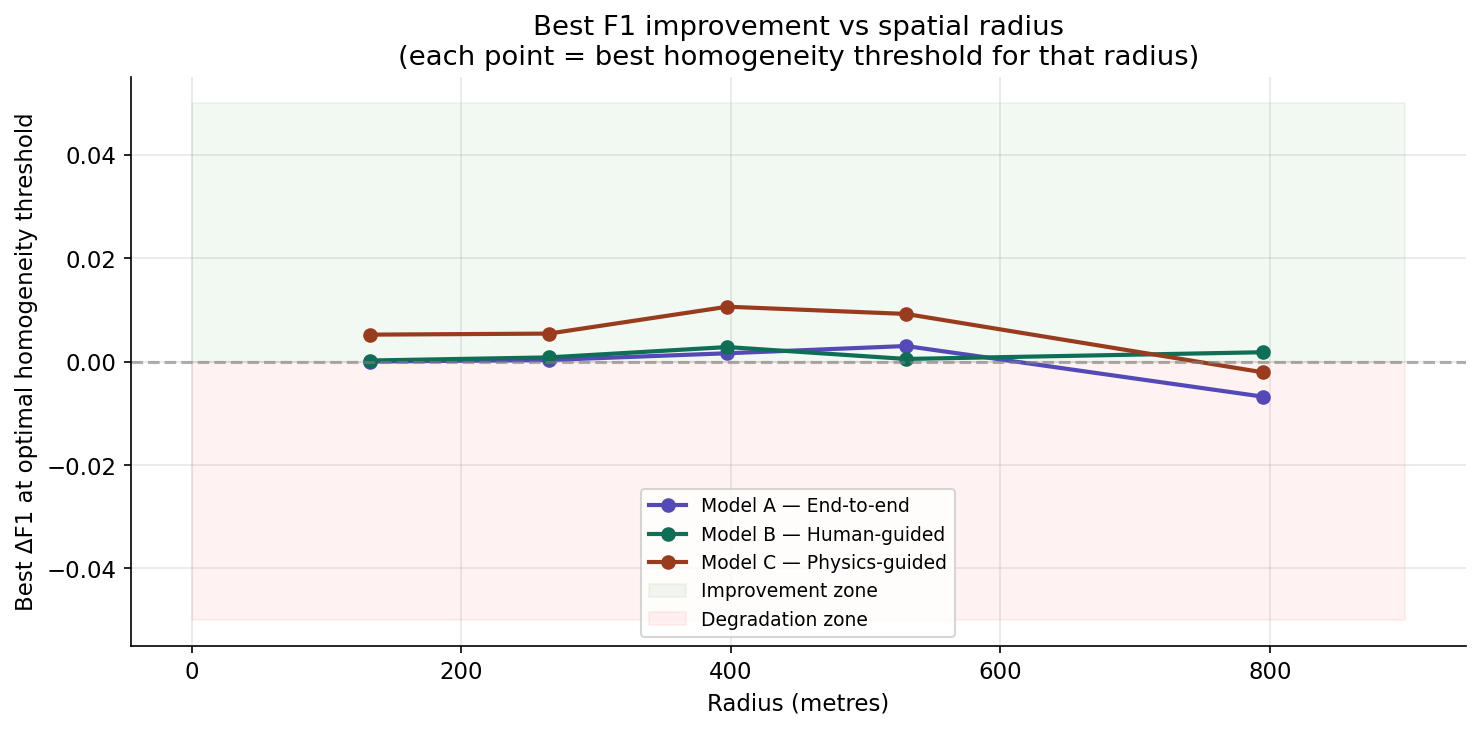

Saved: fig2_delta_f1_by_model.png


In [5]:
def plot_delta_f1_by_model(results):
    fig, ax = plt.subplots(figsize=(10, 5))

    for model_id, res in results.items():
        radii_m     = [rr["radius_m"]      for rr in res["radius_results"]]
        best_deltas = [rr["best_delta_f1"] for rr in res["radius_results"]]
        ax.plot(radii_m, best_deltas,
                label=LABELS[model_id], color=COLORS[model_id],
                linewidth=2, marker="o", markersize=6)

    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.6)
    ax.fill_between([0, 900],  0,  0.05, alpha=0.05, color="green",
                    label="Improvement zone")
    ax.fill_between([0, 900], -0.05, 0,  alpha=0.05, color="red",
                    label="Degradation zone")
    ax.set_xlabel("Radius (metres)")
    ax.set_ylabel("Best \u0394F1 at optimal homogeneity threshold")
    ax.set_title("Best F1 improvement vs spatial radius\n"
                 "(each point = best homogeneity threshold for that radius)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    path = FIGURES_DIR / "fig2_delta_f1_by_model.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


plot_delta_f1_by_model(results)

***4. Figure 3 — Baseline vs best clustering F1***

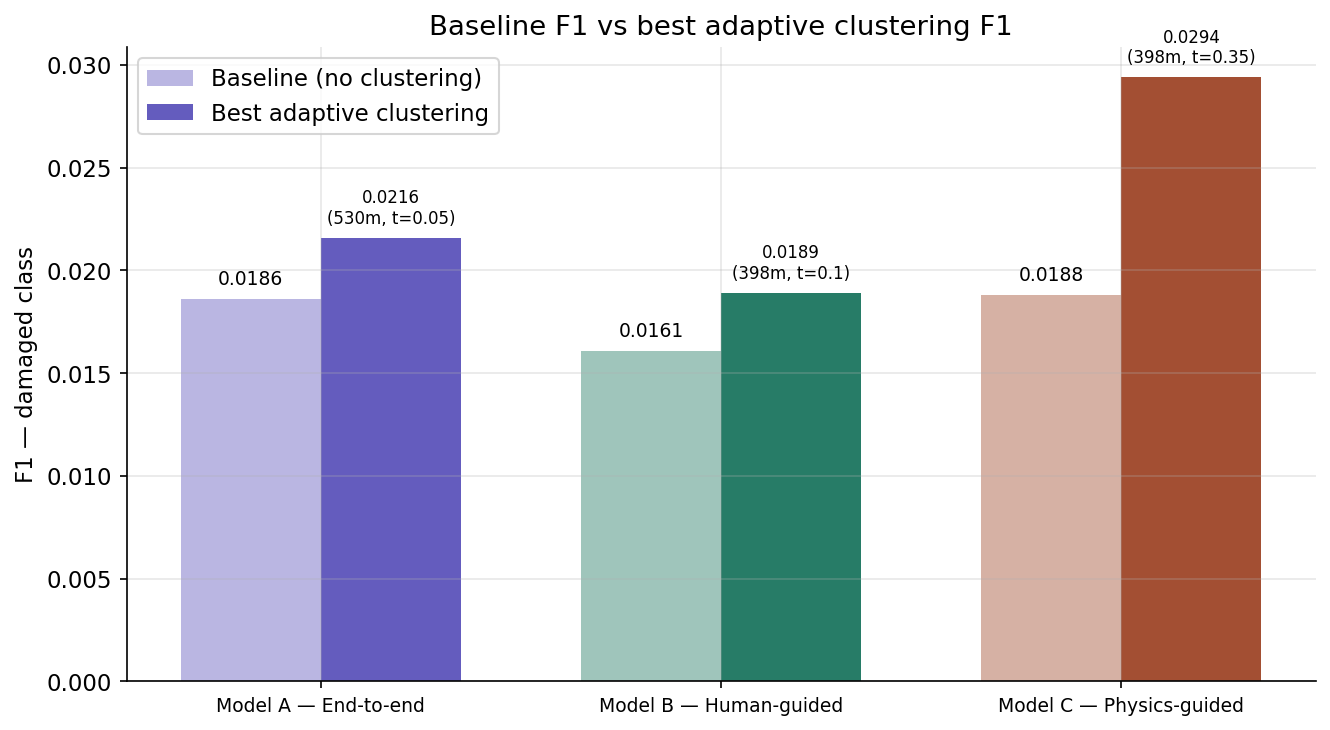

Saved: fig3_f1_comparison.png


In [6]:
def plot_f1_comparison(results):
    models      = list(results.keys())
    baseline_f1 = [results[m]["baseline"]["f1"] for m in models]
    best_f1     = [results[m]["best_f1"]        for m in models]
    best_r      = [results[m]["best_radius_m"]  for m in models]
    best_t      = [results[m]["best_hom_threshold"] for m in models]

    x     = np.arange(len(models))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))

    bars1 = ax.bar(x - width/2, baseline_f1, width,
                   label="Baseline (no clustering)",
                   color=[COLORS[m] for m in models], alpha=0.4)
    bars2 = ax.bar(x + width/2, best_f1, width,
                   label="Best adaptive clustering",
                   color=[COLORS[m] for m in models], alpha=0.9)

    for bar, val in zip(bars1, baseline_f1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    for bar, val, r, t in zip(bars2, best_f1, best_r, best_t):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f"{val:.4f}\n({r:.0f}m, t={t})",
                ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel("F1 \u2014 damaged class")
    ax.set_title("Baseline F1 vs best adaptive clustering F1")
    ax.legend()
    fig.tight_layout()
    path = FIGURES_DIR / "fig3_f1_comparison.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


plot_f1_comparison(results)

***5. Figure 4 — Mean neighbourhood size vs radius***

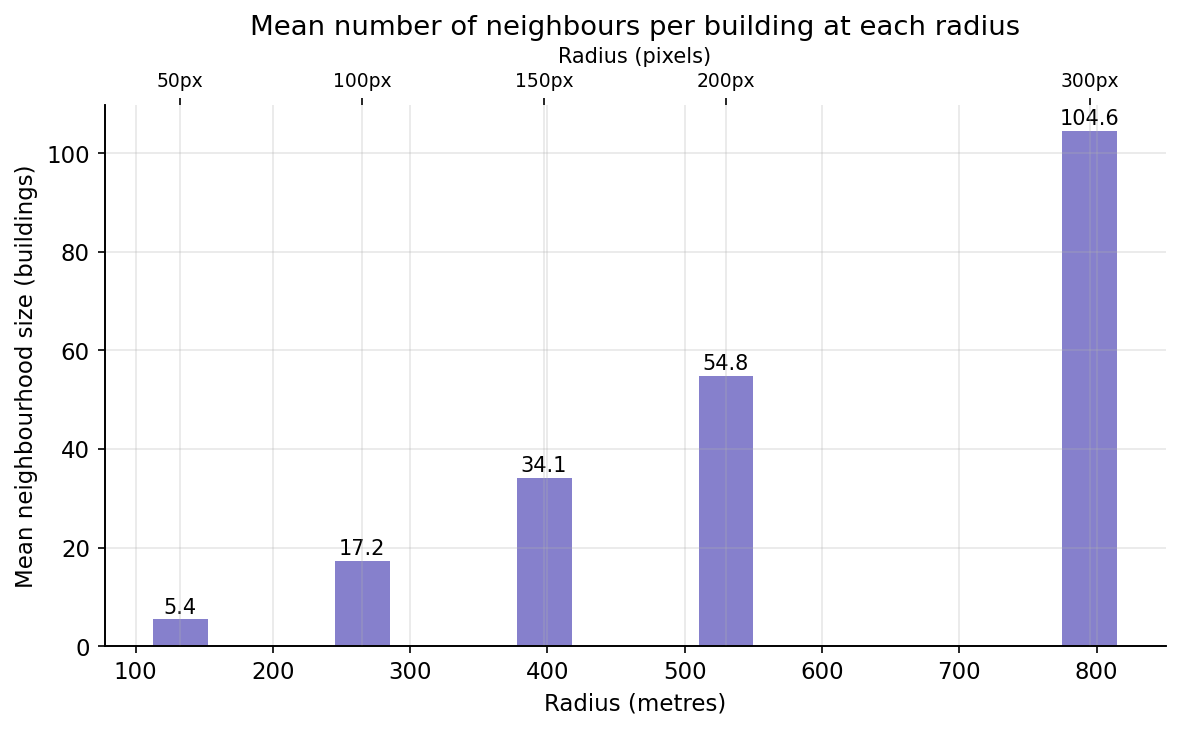

Saved: fig4_neighbourhood_size.png


In [7]:
def plot_neighbourhood_size(results):
    fig, ax = plt.subplots(figsize=(8, 5))

    first_model = list(results.values())[0]
    radii_px    = [rr["radius_px"]          for rr in first_model["radius_results"]]
    radii_m     = [rr["radius_m"]           for rr in first_model["radius_results"]]
    mean_sizes  = [rr["neighbourhood_mean"] for rr in first_model["radius_results"]]

    ax.bar(radii_m, mean_sizes, width=40, color="#534AB7", alpha=0.7)
    for r, s in zip(radii_m, mean_sizes):
        ax.text(r, s + 0.5, f"{s:.1f}", ha="center", va="bottom", fontsize=10)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_m)
    ax2.set_xticklabels([f"{r}px" for r in radii_px], fontsize=9)
    ax2.set_xlabel("Radius (pixels)", fontsize=10)

    ax.set_xlabel("Radius (metres)")
    ax.set_ylabel("Mean neighbourhood size (buildings)")
    ax.set_title("Mean number of neighbours per building at each radius")
    fig.tight_layout()
    path = FIGURES_DIR / "fig4_neighbourhood_size.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


plot_neighbourhood_size(results)